In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("✅ Packages imported successfully!")

✅ Packages imported successfully!


## 1. Load Model Results

In [198]:
# ==========================================
# LOAD MODEL RESULTS FROM PKL FILES
# ==========================================

print("Loading model results...")

# Load all model pkl files
models_data = {
    'SVM': joblib.load('../models/svm_binary_dimensions_upsampled.pkl'),
    'Logistic Regression': joblib.load('../models/logistic_regression_binary_dimensions_optimal.pkl'),
    'Naive Bayes (BOW)': joblib.load('../models/naive_bayes_BOW.pkl'),
    'Naive Bayes (TF-IDF)': joblib.load('../models/naive_bayes_TF-IDF.pkl')
}

print(f"✅ Loaded {len(models_data)} models:")
for model_name in models_data.keys():
    print(f"   - {model_name}")

# Extract dimensions (should be same for all models)
dimensions = models_data['SVM']['dimensions']
print(f"✅ Dimensions: {dimensions}")

Loading model results...
✅ Loaded 4 models:
   - SVM
   - Logistic Regression
   - Naive Bayes (BOW)
   - Naive Bayes (TF-IDF)
✅ Dimensions: ['I/E', 'N/S', 'T/F', 'J/P']


## 2. F1-Score Comparison per Dimension

Compare F1-scores across all models for each MBTI dimension.
F1-score is preferred over accuracy for imbalanced classification tasks.

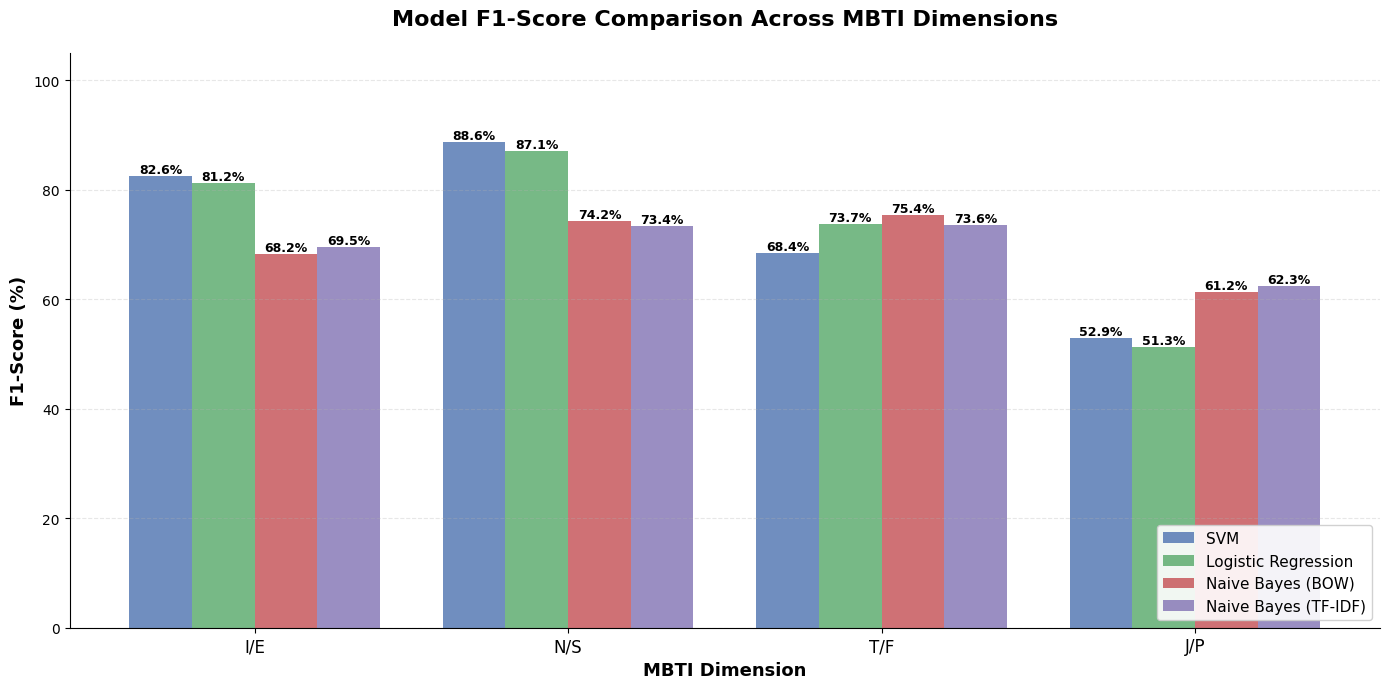


✅ F1-Score comparison chart generated!


In [199]:
# Extract F1-scores for each model and dimension
f1_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        f1_score = model_info['metrics'][dim]['f1_score']
        f1_data.append({
            'Model': model_name,
            'Dimension': dim,
            'F1-Score': f1_score
        })

f1_df = pd.DataFrame(f1_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Set up positions for grouped bars
x = np.arange(len(dimensions))
width = 0.2
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# Plot bars for each model
for i, model_name in enumerate(model_names):
    model_f1_scores = [f1_df[(f1_df['Model'] == model_name) & 
                             (f1_df['Dimension'] == dim)]['F1-Score'].values[0] 
                       for dim in dimensions]
    bars = ax.bar(x + i * width, model_f1_scores, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontsize=13, fontweight='bold')
ax.set_title('Model F1-Score Comparison Across MBTI Dimensions', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dimensions, fontsize=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ F1-Score comparison chart generated!")

## 3. Comprehensive Metrics Heatmap

View all performance metrics (Accuracy, F1-Score, Precision, Recall, CV Score) across models and dimensions.

C:\Users\Stijn\AppData\Local\Temp\ipykernel_25612\345669272.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.96])


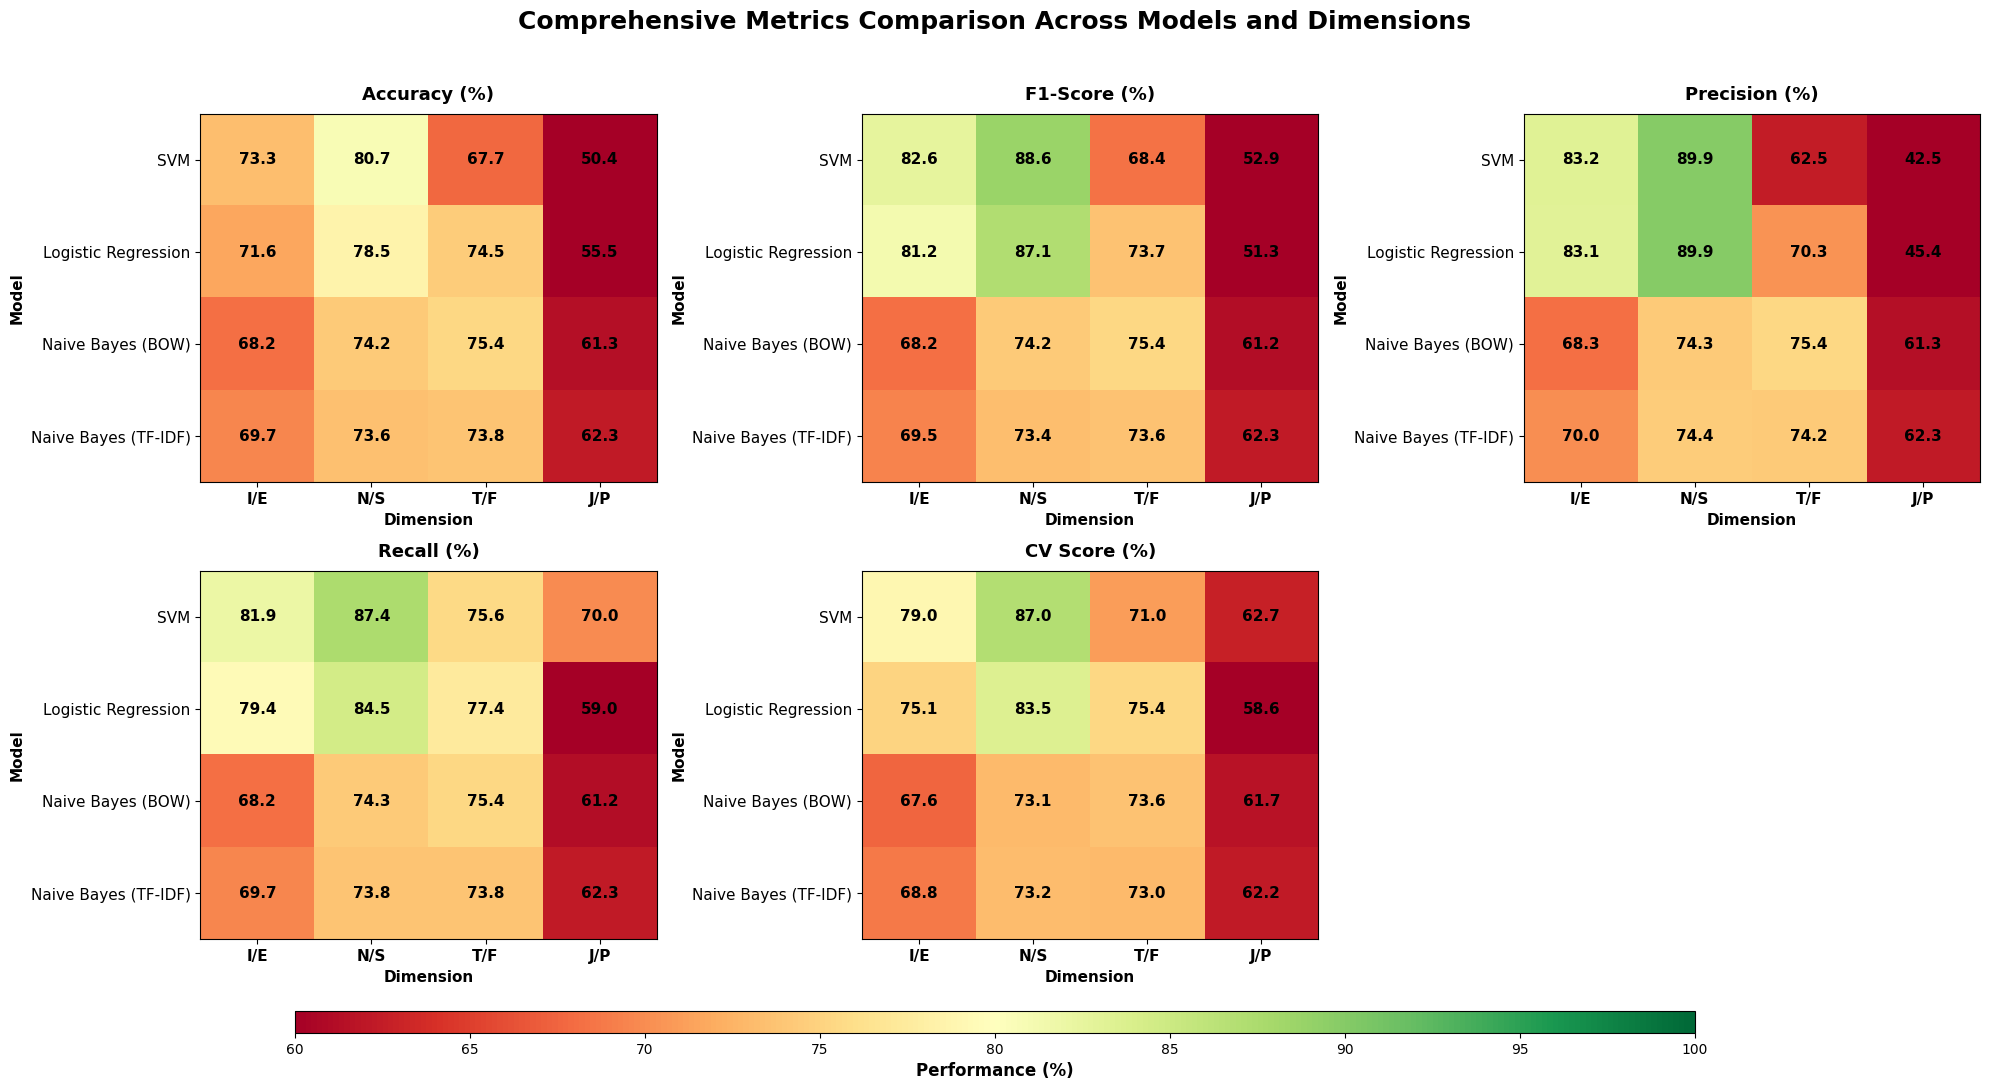


✅ Comprehensive metrics heatmap generated!


In [200]:
# Create comprehensive metrics comparison
metrics_to_compare = ['accuracy', 'f1_score', 'precision', 'recall', 'cv_score']
metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'CV Score']

# Create subplots for each metric
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metrics_to_compare, metric_labels)):
    ax = axes[idx]
    
    # Prepare data matrix
    data_matrix = []
    for model_name in models_data.keys():
        row = [models_data[model_name]['metrics'][dim][metric] for dim in dimensions]
        data_matrix.append(row)
    
    # Create heatmap
    im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=60, vmax=100)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(dimensions)))
    ax.set_yticks(np.arange(len(models_data)))
    ax.set_xticklabels(dimensions, fontsize=11, fontweight='bold')
    ax.set_yticklabels(models_data.keys(), fontsize=11)
    
    # Rotate the tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    # Add values to cells
    for i in range(len(models_data)):
        for j in range(len(dimensions)):
            text = ax.text(j, i, f'{data_matrix[i][j]:.1f}',
                          ha="center", va="center", color="black", 
                          fontsize=11, fontweight='bold')
    
    ax.set_title(f'{label} (%)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Dimension', fontsize=11, fontweight='bold')
    ax.set_ylabel('Model', fontsize=11, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

# Add colorbar at the bottom
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Performance (%)', fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Metrics Comparison Across Models and Dimensions', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

print("\n✅ Comprehensive metrics heatmap generated!")

## 4. Overfitting Analysis

Compare train vs. test performance to identify which models generalize well vs. overfit to training data.

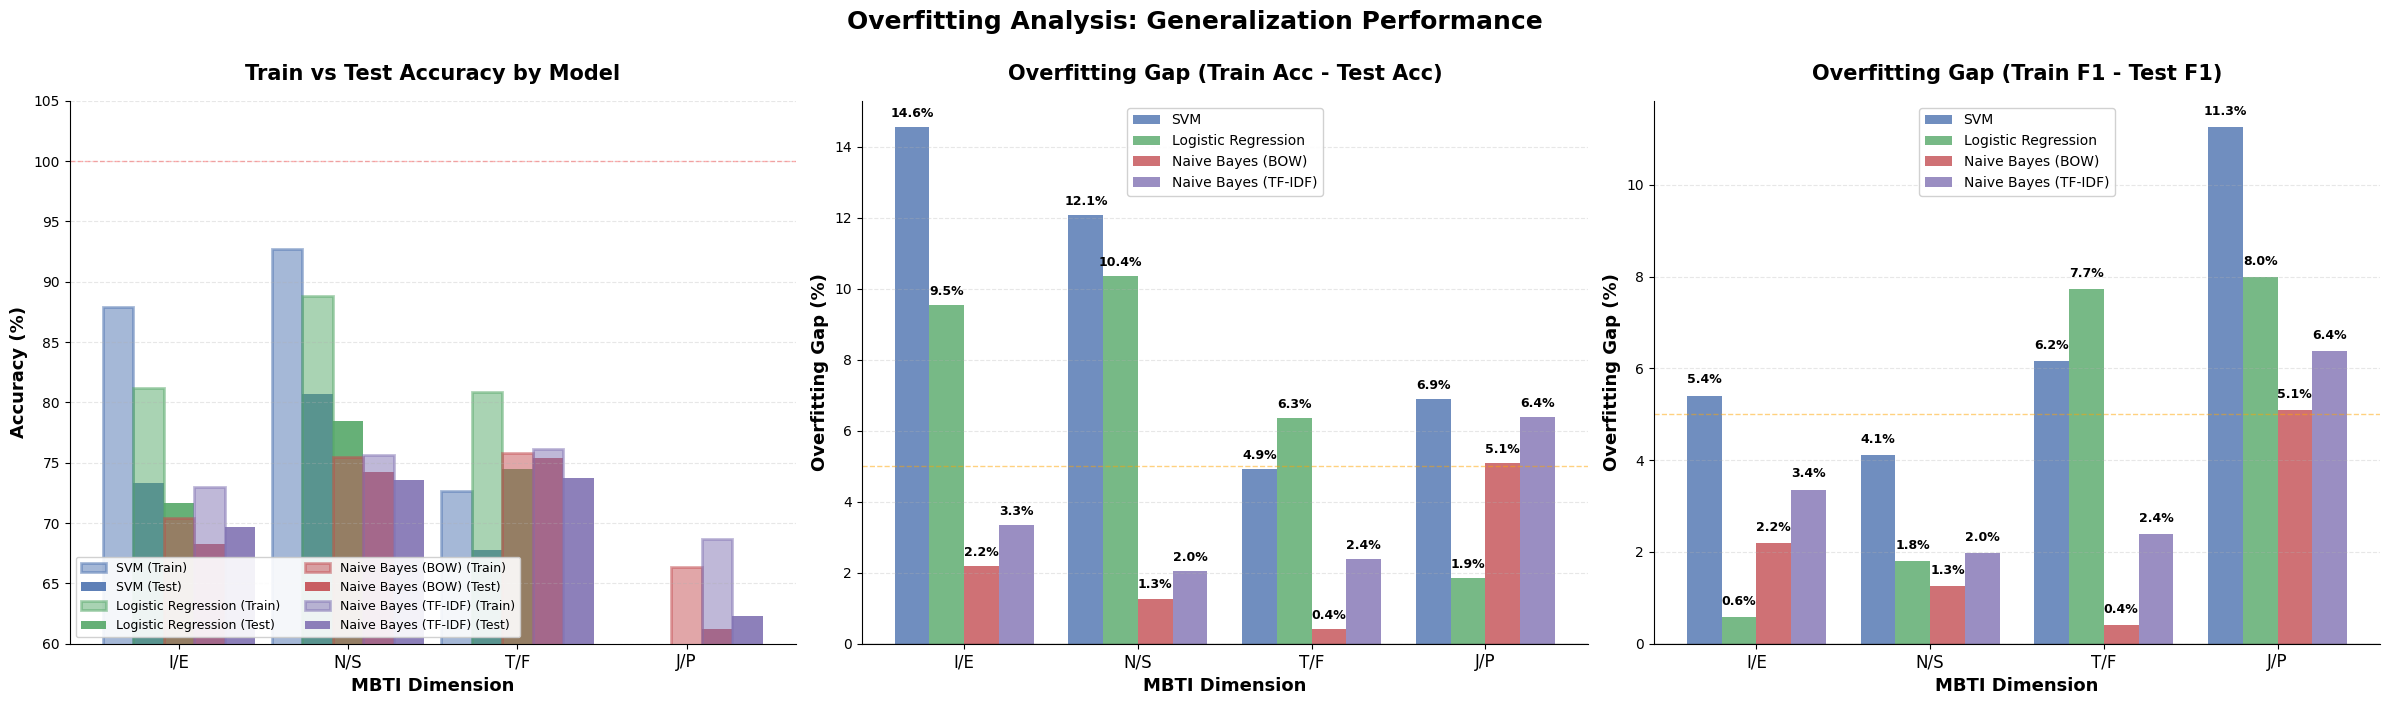

In [201]:
# Extract overfitting gap (train_accuracy - test_accuracy) for each model
overfitting_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        train_acc = model_info['metrics'][dim]['train_accuracy']
        test_acc = model_info['metrics'][dim]['accuracy']
        overfit_gap_acc = model_info['metrics'][dim]['overfit_gap']
        
        # F1-score overfitting gap
        train_f1 = model_info['metrics'][dim]['train_f1']
        test_f1 = model_info['metrics'][dim]['f1_score']
        overfit_gap_f1 = train_f1 - test_f1
        
        overfitting_data.append({
            'Model': model_name,
            'Dimension': dim,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Overfitting Gap (Acc)': overfit_gap_acc,
            'Train F1': train_f1,
            'Test F1': test_f1,
            'Overfitting Gap (F1)': overfit_gap_f1
        })

overfit_df = pd.DataFrame(overfitting_data)

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

# --- Left plot: Train vs Test Accuracy Comparison ---
x = np.arange(len(dimensions))
width = 0.35
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# For each model, show train and test accuracy side by side
bar_width = 0.18
for i, model_name in enumerate(model_names):
    model_data = overfit_df[overfit_df['Model'] == model_name]
    
    train_accs = model_data['Train Accuracy'].values
    test_accs = model_data['Test Accuracy'].values
    
    x_pos = x + i * bar_width
    ax1.bar(x_pos - bar_width/2, train_accs, bar_width, 
            label=f'{model_name} (Train)', color=colors[i], alpha=0.5, edgecolor=colors[i], linewidth=2)
    ax1.bar(x_pos + bar_width/2, test_accs, bar_width, 
            label=f'{model_name} (Test)', color=colors[i], alpha=0.9)

ax1.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('Train vs Test Accuracy by Model', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(dimensions, fontsize=12)
ax1.legend(loc='lower left', fontsize=9, ncol=2, framealpha=0.9)
ax1.set_ylim(60, 105)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=100, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Middle plot: Accuracy Overfitting Gap ---
x = np.arange(len(dimensions))
width = 0.2

for i, model_name in enumerate(model_names):
    model_gaps = [overfit_df[(overfit_df['Model'] == model_name) & 
                             (overfit_df['Dimension'] == dim)]['Overfitting Gap (Acc)'].values[0] 
                  for dim in dimensions]
    bars = ax2.bar(x + i * width, model_gaps, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax2.set_ylabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax2.set_title('Overfitting Gap (Train Acc - Test Acc)', fontsize=15, fontweight='bold', pad=15)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(dimensions, fontsize=12)
ax2.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Right plot: F1-Score Overfitting Gap ---
x = np.arange(len(dimensions))
width = 0.2

for i, model_name in enumerate(model_names):
    model_gaps_f1 = [overfit_df[(overfit_df['Model'] == model_name) & 
                                (overfit_df['Dimension'] == dim)]['Overfitting Gap (F1)'].values[0] 
                     for dim in dimensions]
    bars = ax3.bar(x + i * width, model_gaps_f1, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax3.set_ylabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax3.set_title('Overfitting Gap (Train F1 - Test F1)', fontsize=15, fontweight='bold', pad=15)
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels(dimensions, fontsize=12)
ax3.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle('Overfitting Analysis: Generalization Performance', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()